# SpaceX Falcon 9 – Machine Learning Prediction
Predict whether the first stage will land successfully using Logistic Regression, SVM, Decision Tree and KNN, tuned with `GridSearchCV` (cv = 10).

In [1]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y, y_predict, title, path=None):
    cm = confusion_matrix(y, y_predict)
    ax = plt.subplot()
    sns.heatmap(cm, annot=True, ax=ax, cmap='Blues', annot_kws={'size': 16})
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.set_title(title)
    ax.xaxis.set_ticklabels(['did not land', 'land'])
    ax.yaxis.set_ticklabels(['did not land', 'landed'])
    if path:
        plt.savefig(path, bbox_inches='tight', dpi=110)
    plt.show()

In [2]:
data = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv')
X = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_3.csv')

## Task 1–3: Label, standardize and split the data

In [3]:
Y = data['Class'].to_numpy()
transform = preprocessing.StandardScaler()
X = transform.fit(X).transform(X)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)
print('Test samples:', Y_test.shape[0])

Test samples: 18


## Task 4–5: Logistic Regression

tuned hyperparameters: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
validation accuracy: 0.8464285714285713
test accuracy: 0.8333333333333334


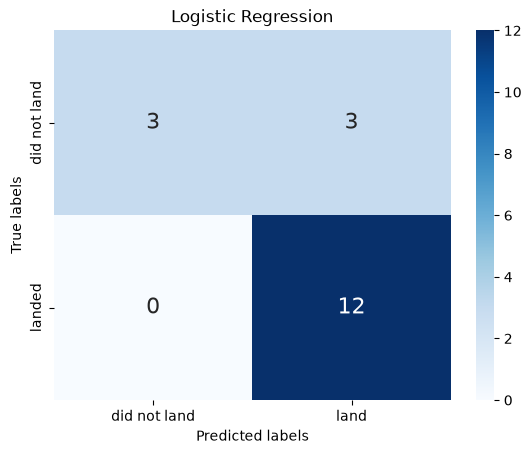

In [4]:
parameters = {'C': [0.01, 0.1, 1], 'penalty': ['l2'], 'solver': ['lbfgs']}
logreg_cv = GridSearchCV(LogisticRegression(), parameters, cv=10).fit(X_train, Y_train)
print("tuned hyperparameters:", logreg_cv.best_params_)
print("validation accuracy:", logreg_cv.best_score_)
print("test accuracy:", logreg_cv.score(X_test, Y_test))
plot_confusion_matrix(Y_test, logreg_cv.predict(X_test), 'Logistic Regression')

## Task 6–7: Support Vector Machine

tuned hyperparameters: {'C': np.float64(1.0), 'gamma': np.float64(0.03162277660168379), 'kernel': 'sigmoid'}
validation accuracy: 0.8482142857142856
test accuracy: 0.8333333333333334


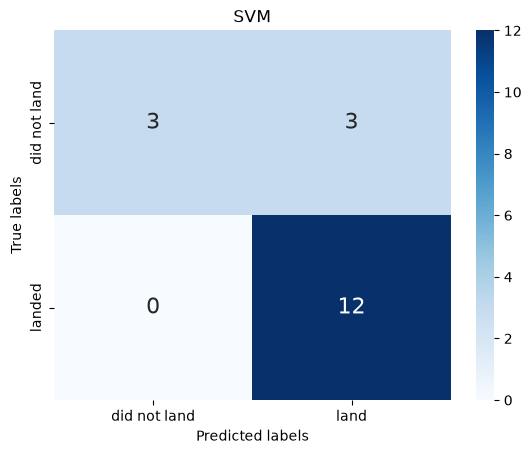

In [5]:
parameters = {'kernel': ('linear', 'rbf', 'poly', 'rbf', 'sigmoid'),
              'C': np.logspace(-3, 3, 5), 'gamma': np.logspace(-3, 3, 5)}
svm_cv = GridSearchCV(SVC(), parameters, cv=10).fit(X_train, Y_train)
print("tuned hyperparameters:", svm_cv.best_params_)
print("validation accuracy:", svm_cv.best_score_)
print("test accuracy:", svm_cv.score(X_test, Y_test))
plot_confusion_matrix(Y_test, svm_cv.predict(X_test), 'SVM')

## Task 8–9: Decision Tree

tuned hyperparameters: {'criterion': 'gini', 'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'splitter': 'random'}
validation accuracy: 0.8482142857142858
test accuracy: 0.8333333333333334


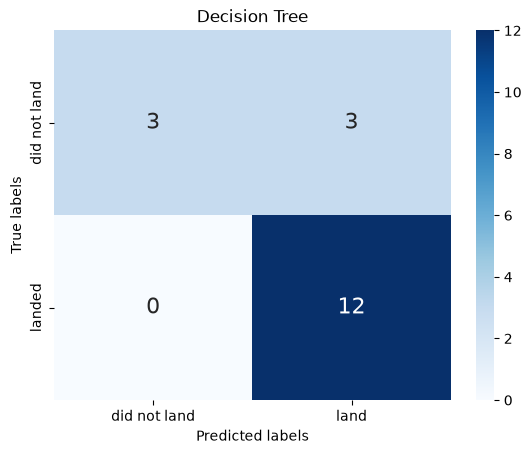

In [6]:
parameters = {'criterion': ['gini', 'entropy'], 'splitter': ['best', 'random'],
              'max_depth': [2 * n for n in range(1, 10)], 'max_features': ['sqrt'],
              'min_samples_leaf': [1, 2, 4], 'min_samples_split': [2, 5, 10]}
tree_cv = GridSearchCV(DecisionTreeClassifier(random_state=12), parameters, cv=10).fit(X_train, Y_train)
print("tuned hyperparameters:", tree_cv.best_params_)
print("validation accuracy:", tree_cv.best_score_)
print("test accuracy:", tree_cv.score(X_test, Y_test))
plot_confusion_matrix(Y_test, tree_cv.predict(X_test), 'Decision Tree')

## Task 10–11: K Nearest Neighbors

tuned hyperparameters: {'algorithm': 'auto', 'n_neighbors': 10, 'p': 1}
validation accuracy: 0.8482142857142858
test accuracy: 0.8333333333333334


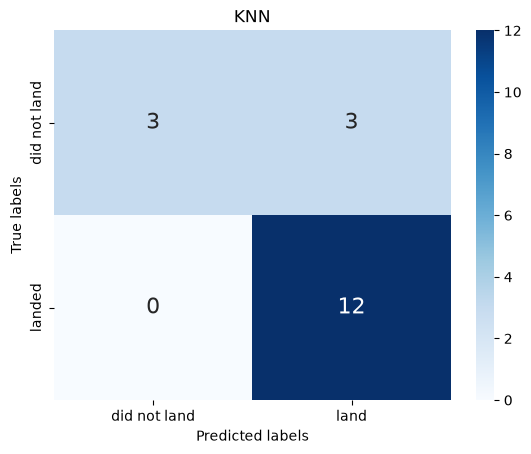

In [7]:
parameters = {'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
              'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'], 'p': [1, 2]}
knn_cv = GridSearchCV(KNeighborsClassifier(), parameters, cv=10).fit(X_train, Y_train)
print("tuned hyperparameters:", knn_cv.best_params_)
print("validation accuracy:", knn_cv.best_score_)
print("test accuracy:", knn_cv.score(X_test, Y_test))
plot_confusion_matrix(Y_test, knn_cv.predict(X_test), 'KNN')

## Task 12: Find the method that performs best

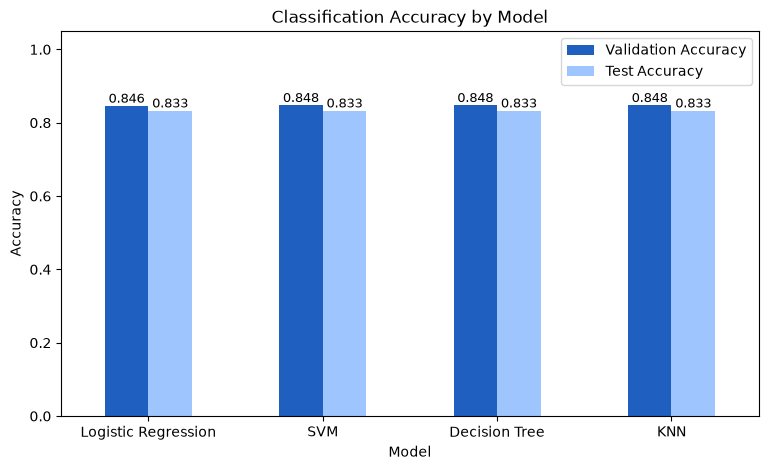

Best model: SVM


,Model,Validation Accuracy,Test Accuracy
0,Logistic Regression,0.8464,0.8333
1,SVM,0.8482,0.8333
2,Decision Tree,0.8482,0.8333
3,KNN,0.8482,0.8333


In [8]:
models = {'Logistic Regression': logreg_cv, 'SVM': svm_cv, 'Decision Tree': tree_cv, 'KNN': knn_cv}
results = pd.DataFrame({
    'Model': list(models),
    'Validation Accuracy': [m.best_score_ for m in models.values()],
    'Test Accuracy': [m.score(X_test, Y_test) for m in models.values()],
}).round(4)
results.to_csv('results/ml_results.csv', index=False)

ax = results.plot(x='Model', y=['Validation Accuracy', 'Test Accuracy'], kind='bar', figsize=(9, 5),
                  color=['#1f5fbf', '#9ec5fe'], rot=0)
for c in ax.containers:
    ax.bar_label(c, fmt='%.3f', fontsize=9)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Accuracy')
ax.set_title('Classification Accuracy by Model')
plt.savefig('images/ml_accuracy.png', bbox_inches='tight', dpi=110)
plt.show()

best_name = results.sort_values(['Validation Accuracy', 'Test Accuracy'], ascending=False).iloc[0]['Model']
print("Best model:", best_name)
results

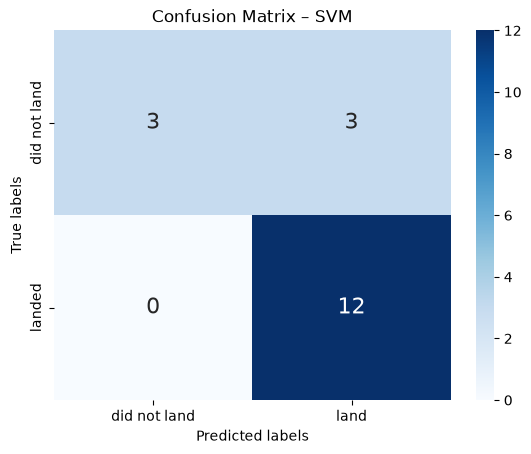

In [9]:
plot_confusion_matrix(Y_test, models[best_name].predict(X_test), f'Confusion Matrix – {best_name}',
                      path='images/ml_confusion_best.png')